# Phase 3 — Exploratory Data Analysis (EDA)
**Project:** E-Commerce Customer Behavior ML

| Step | Analysis |
|---|---|
| 0 | Setup & load cleaned data |
| 1 | User demographics & segmentation |
| 2 | Session & browsing behavior |
| 3 | Purchase funnel analysis |
| 4 | Product performance |
| 5 | RFM analysis (Recency · Frequency · Monetary) |
| 6 | Correlation heatmap |
| 7 | Key insights summary |


## Step 0 — Setup & Load Cleaned Data

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Dynamic paths ─────────────────────────────────────────────────────────────
_cwd          = Path().resolve()
_candidates   = [_cwd / 'data' / 'processed', _cwd.parent / 'data' / 'processed']
PROCESSED_DIR = next((p for p in _candidates if p.exists()), None)

if PROCESSED_DIR is None:
    raise FileNotFoundError("data/processed/ not found. Run Phase 2 notebook first.")

PROJECT_ROOT = PROCESSED_DIR.parent.parent
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
sns.set_palette('Set2')
COLORS = sns.color_palette('Set2').as_hex()

# ── Load cleaned tables ───────────────────────────────────────────────────────
def load(name):
    p = PROCESSED_DIR / f'{name}.parquet'
    if p.exists(): return pd.read_parquet(p)
    return pd.read_csv(PROCESSED_DIR / f'{name}.csv')

users         = load('users')
products      = load('products')
sessions      = load('sessions')
browse_events = load('browse_events')
orders        = load('orders')
order_items   = load('order_items')
cart_signals  = load('user_cart_signals')

# Parse datetimes
sessions['session_start'] = pd.to_datetime(sessions['session_start'])
orders['order_date']      = pd.to_datetime(orders['order_date'])

print("Cleaned tables loaded:")
for name, df in [('users',users),('products',products),('sessions',sessions),
                 ('browse_events',browse_events),('orders',orders),
                 ('order_items',order_items),('cart_signals',cart_signals)]:
    print(f"  {name:<20} {len(df):>8,} rows  |  {df.shape[1]} cols")

Cleaned tables loaded:
  users                   5,000 rows  |  18 cols
  products                  500 rows  |  9 cols
  sessions               20,000 rows  |  24 cols
  browse_events          89,016 rows  |  10 cols
  orders                  8,000 rows  |  15 cols
  order_items            23,958 rows  |  5 cols
  cart_signals            4,465 rows  |  7 cols


## Step 1 — User Demographics & Segmentation

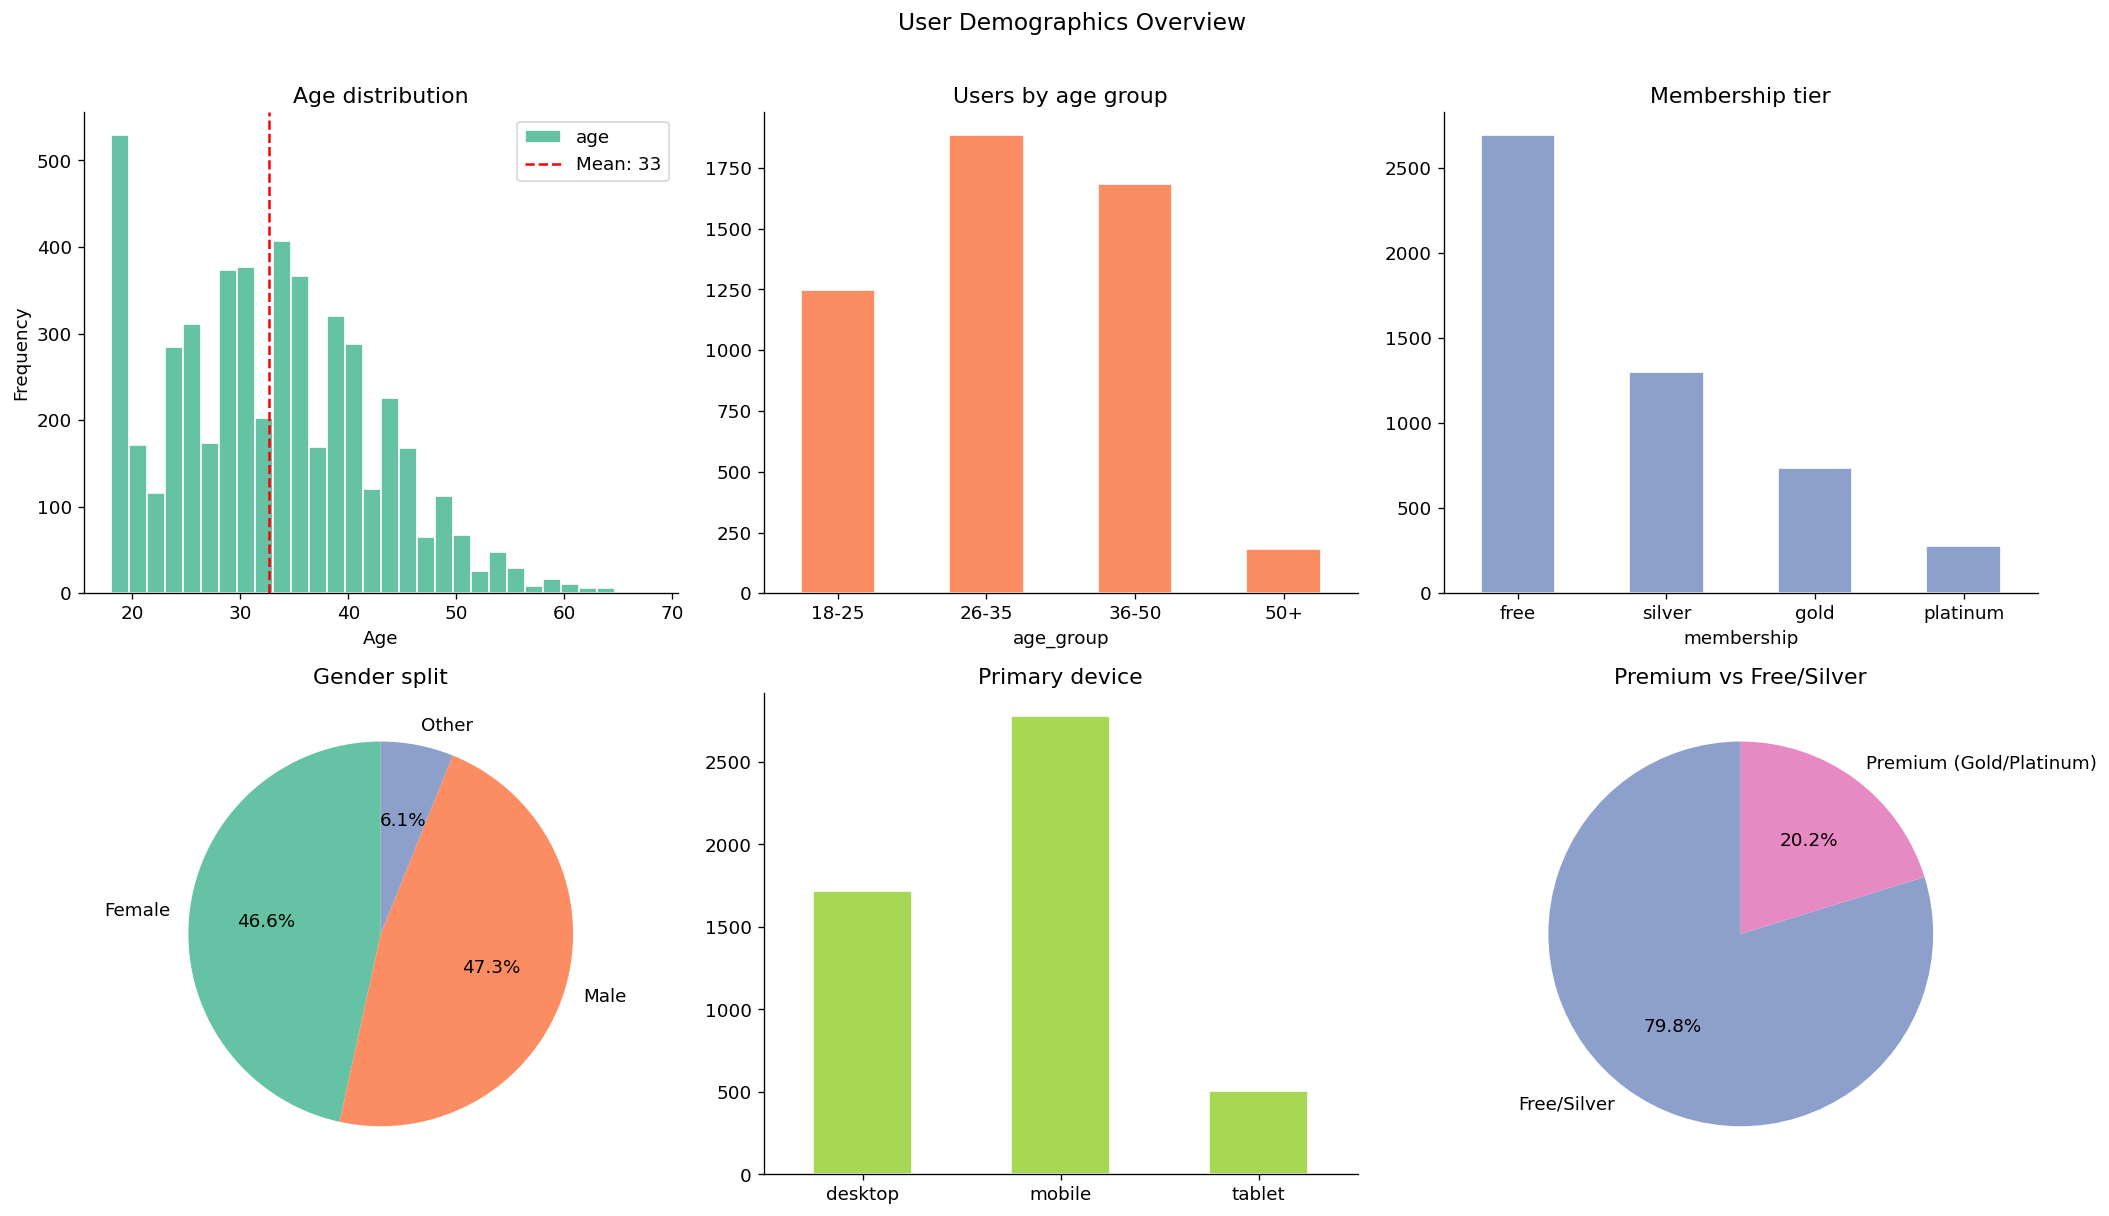

Chart saved → 03_user_demographics.png


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age distribution
users['age'].plot(kind='hist', bins=30, ax=axes[0][0],
                  edgecolor='white', color=COLORS[0])
axes[0][0].axvline(users['age'].mean(), color='red', linestyle='--', label=f"Mean: {users['age'].mean():.0f}")
axes[0][0].set_title('Age distribution')
axes[0][0].set_xlabel('Age')
axes[0][0].legend()

# Age group
if 'age_group' in users.columns:
    users['age_group'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0][1], edgecolor='white', color=COLORS[1])
    axes[0][1].set_title('Users by age group')
    axes[0][1].tick_params(axis='x', rotation=0)

# Membership tier
mem_counts = users['membership'].value_counts()
mem_order  = ['free','silver','gold','platinum']
mem_counts = mem_counts.reindex([m for m in mem_order if m in mem_counts.index])
mem_counts.plot(kind='bar', ax=axes[0][2], edgecolor='white', color=COLORS[2])
axes[0][2].set_title('Membership tier')
axes[0][2].tick_params(axis='x', rotation=0)

# Gender split
gender_cols = [c for c in users.columns if c.startswith('gender_')]
if gender_cols:
    gender_sums = users[gender_cols].sum()
    gender_sums.index = [c.replace('gender_','') for c in gender_sums.index]
    gender_sums.plot(kind='pie', ax=axes[1][0], autopct='%1.1f%%', startangle=90)
    axes[1][0].set_title('Gender split')
    axes[1][0].set_ylabel('')

# Device type
dev_cols = [c for c in users.columns if c.startswith('device_')]
if dev_cols:
    dev_sums = users[dev_cols].sum()
    dev_sums.index = [c.replace('device_','') for c in dev_sums.index]
    dev_sums.plot(kind='bar', ax=axes[1][1], edgecolor='white', color=COLORS[4])
    axes[1][1].set_title('Primary device')
    axes[1][1].tick_params(axis='x', rotation=0)

# Premium vs non-premium
if 'is_premium' in users.columns:
    prem = users['is_premium'].map({1:'Premium (Gold/Platinum)', 0:'Free/Silver'})
    prem.value_counts().plot(kind='pie', ax=axes[1][2], autopct='%1.1f%%', startangle=90,
                              colors=[COLORS[2], COLORS[3]])
    axes[1][2].set_title('Premium vs Free/Silver')
    axes[1][2].set_ylabel('')

plt.suptitle('User Demographics Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_user_demographics.png', bbox_inches='tight')
plt.show()
print("Chart saved → 03_user_demographics.png")

In [3]:
# Buyer vs non-buyer profile
buyer_ids    = set(orders['user_id'])
users['is_buyer'] = users['user_id'].isin(buyer_ids).astype(int)

buyer_profile = users.groupby('is_buyer').agg(
    count         = ('user_id',    'count'),
    avg_age       = ('age',        'mean'),
    pct_premium   = ('is_premium', 'mean'),
    avg_acct_days = ('account_age_days', 'mean'),
).round(2)
buyer_profile.index = ['Non-Buyer', 'Buyer']
buyer_profile['pct_premium'] = (buyer_profile['pct_premium'] * 100).round(1)

print("Buyer vs Non-Buyer profile:")
display(buyer_profile)

Buyer vs Non-Buyer profile:


,count,avg_age,pct_premium,avg_acct_days
Non-Buyer,2205,32.830,0.000,338.750
Buyer,2795,32.580,36.000,339.390


## Step 2 — Session & Browsing Behavior

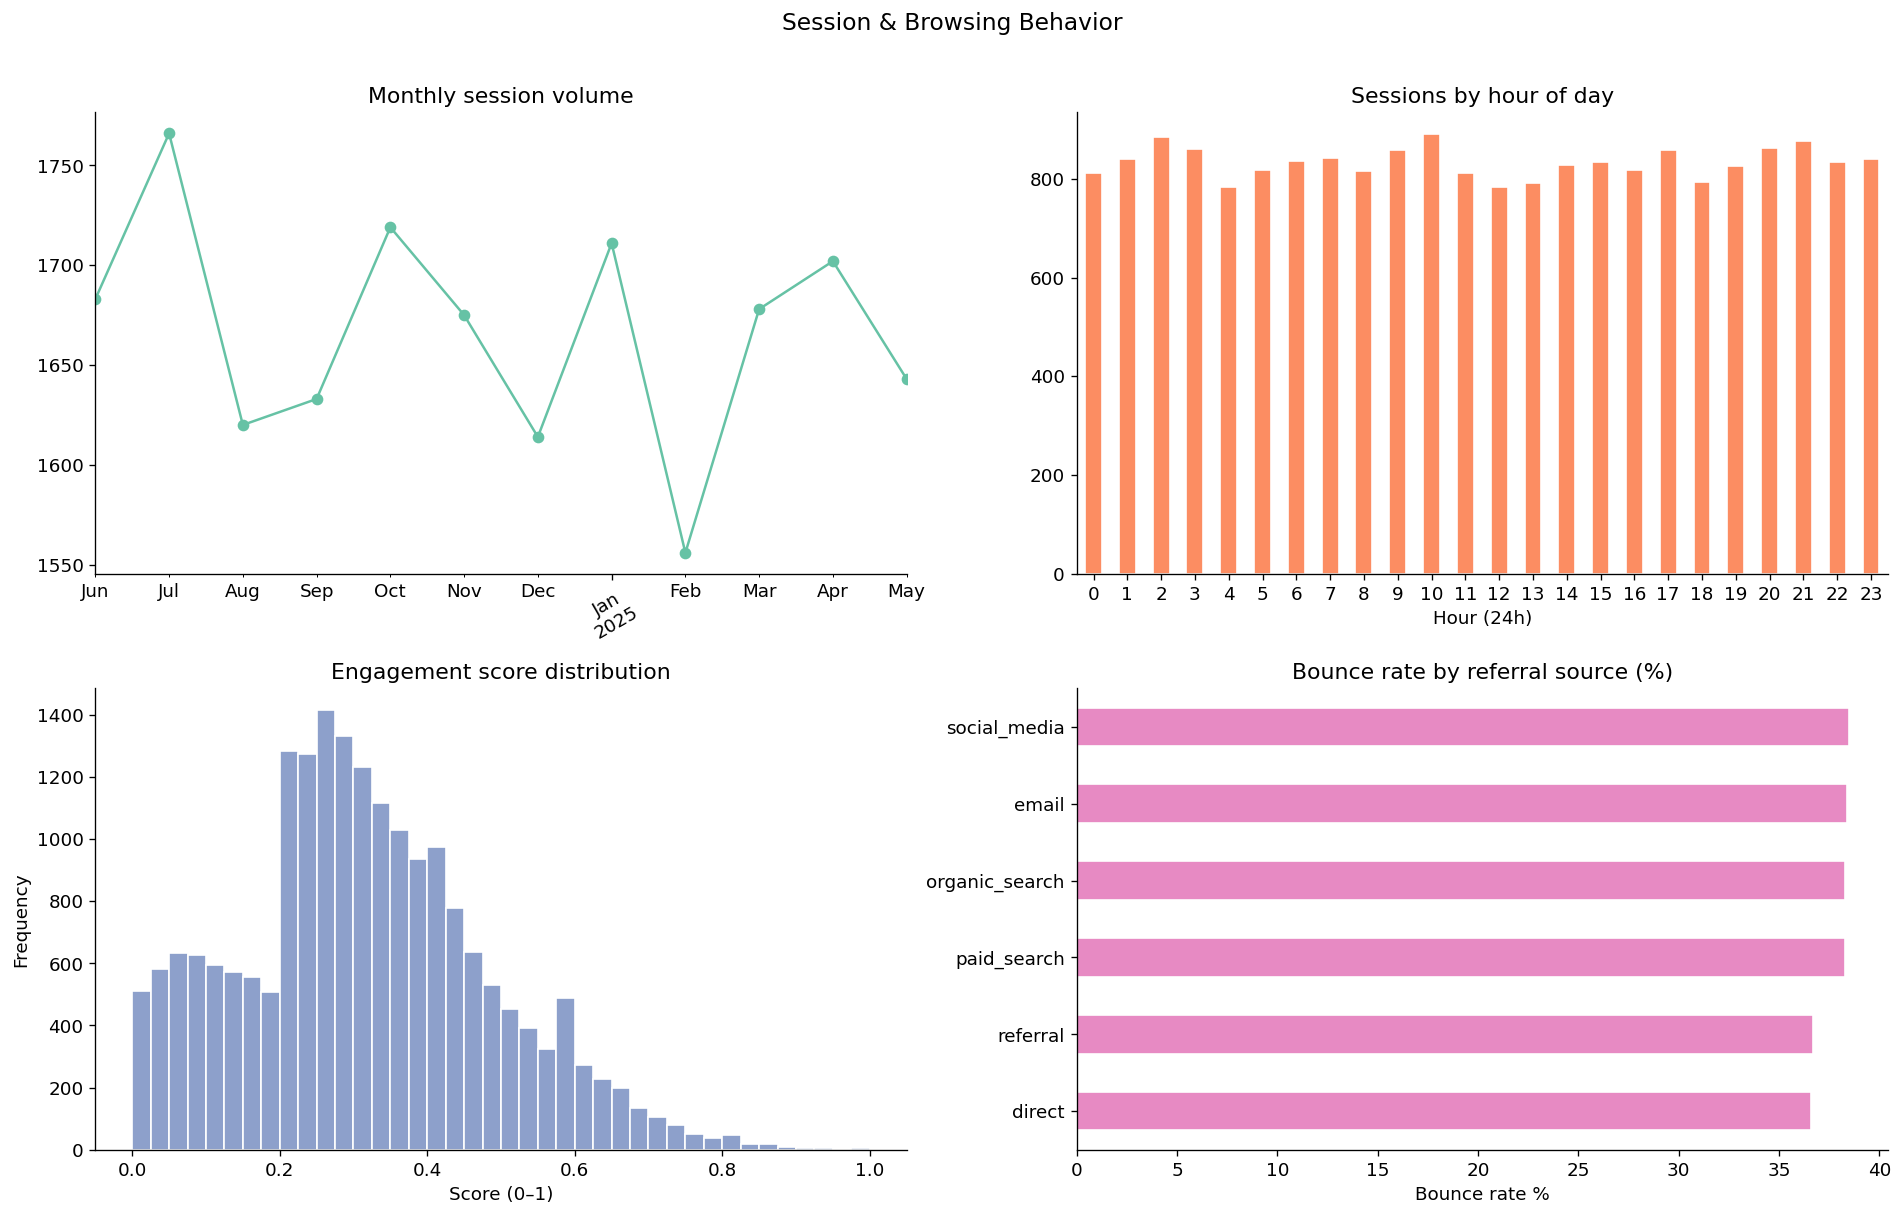

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sessions over time
monthly = sessions.groupby(sessions['session_start'].dt.to_period('M')).size()
monthly.plot(kind='line', marker='o', ax=axes[0][0], color=COLORS[0])
axes[0][0].set_title('Monthly session volume')
axes[0][0].set_xlabel('')
axes[0][0].tick_params(axis='x', rotation=30)

# Hour-of-day pattern
if 'hour_of_day' in sessions.columns:
    sessions.groupby('hour_of_day').size().plot(
        kind='bar', ax=axes[0][1], edgecolor='white', color=COLORS[1])
    axes[0][1].set_title('Sessions by hour of day')
    axes[0][1].set_xlabel('Hour (24h)')
    axes[0][1].tick_params(axis='x', rotation=0)

# Engagement score distribution
if 'engagement_score' in sessions.columns:
    sessions['engagement_score'].plot(
        kind='hist', bins=40, ax=axes[1][0],
        edgecolor='white', color=COLORS[2])
    axes[1][0].set_title('Engagement score distribution')
    axes[1][0].set_xlabel('Score (0–1)')

# Bounce rate by referral source
if 'bounced' in sessions.columns:
    ref_cols = [c for c in sessions.columns if c.startswith('ref_')]
    if ref_cols:
        ref_bounce = {}
        for col in ref_cols:
            subset = sessions[sessions[col] == 1]
            if len(subset) > 0:
                ref_bounce[col.replace('ref_','')] = subset['bounced'].mean() * 100
        pd.Series(ref_bounce).sort_values().plot(
            kind='barh', ax=axes[1][1], edgecolor='white', color=COLORS[3])
        axes[1][1].set_title('Bounce rate by referral source (%)')
        axes[1][1].set_xlabel('Bounce rate %')

plt.suptitle('Session & Browsing Behavior', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_session_behavior.png', bbox_inches='tight')
plt.show()

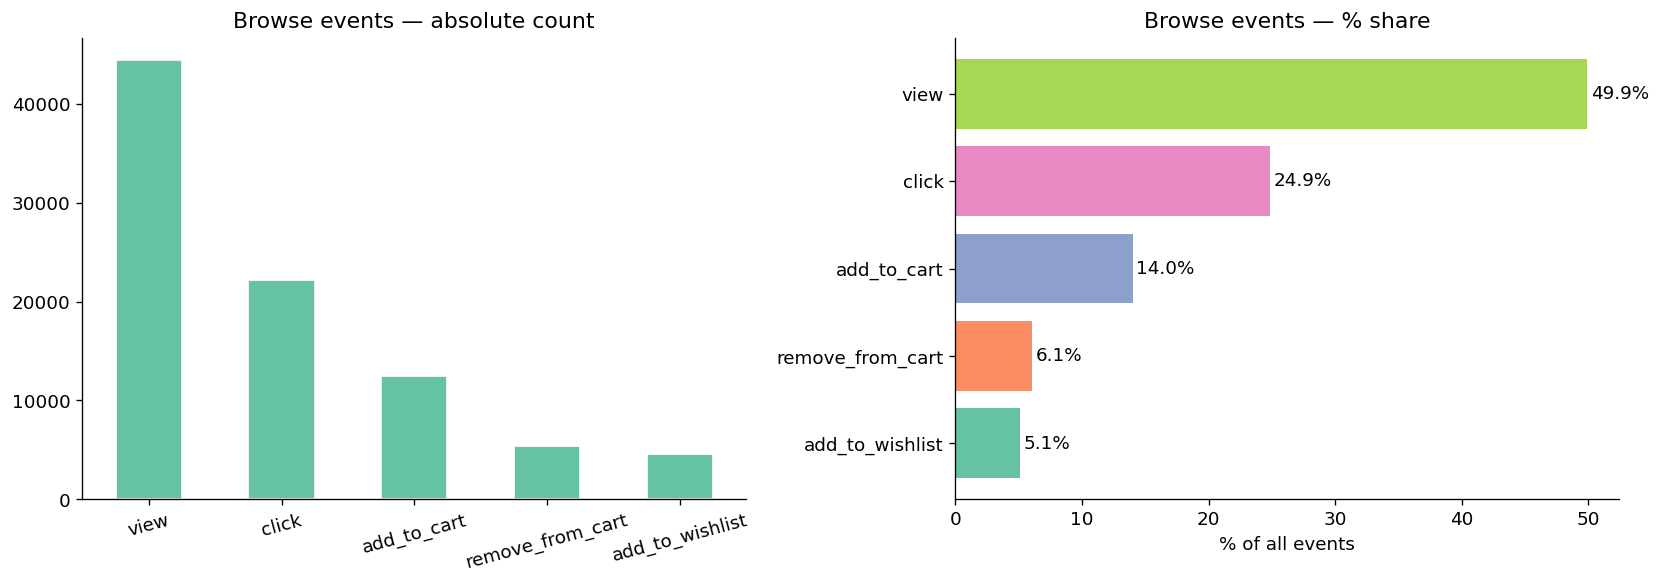


Event breakdown:
                  count    pct
event_type                    
view              44453 49.940
click             22141 24.870
add_to_cart       12466 14.000
remove_from_cart   5400  6.070
add_to_wishlist    4556  5.120


In [5]:
# Browsing event funnel
event_counts = browse_events['event_type'].value_counts().sort_values(ascending=False)
funnel_pct   = (event_counts / len(browse_events) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

event_counts.plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Browse events — absolute count')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# Funnel-style chart
colors_funnel = [COLORS[i % len(COLORS)] for i in range(len(funnel_pct))]
axes[1].barh(funnel_pct.index[::-1], funnel_pct.values[::-1], color=colors_funnel)
for i, (idx, val) in enumerate(zip(funnel_pct.index[::-1], funnel_pct.values[::-1])):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center')
axes[1].set_title('Browse events — % share')
axes[1].set_xlabel('% of all events')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_event_funnel.png', bbox_inches='tight')
plt.show()

print("\nEvent breakdown:")
summary = pd.DataFrame({'count': event_counts, 'pct': funnel_pct})
print(summary.to_string())

## Step 3 — Purchase Funnel Analysis

In [6]:
# Build funnel: users → sessions → browse → cart → order
total_users    = len(users)
active_users   = sessions['user_id'].nunique()
browsed_users  = browse_events['user_id'].nunique()
carted_users   = browse_events[browse_events['event_type']=='add_to_cart']['user_id'].nunique()
ordered_users  = orders['user_id'].nunique()

funnel = pd.DataFrame({
    'Stage':      ['Registered','Had a Session','Browsed Products','Added to Cart','Placed Order'],
    'Users':      [total_users, active_users, browsed_users, carted_users, ordered_users],
})
funnel['Pct of Total'] = (funnel['Users'] / total_users * 100).round(1)
funnel['Drop-off %']   = (1 - funnel['Users'] / funnel['Users'].shift(1)) * 100
funnel['Drop-off %']   = funnel['Drop-off %'].round(1).fillna(0)

print("Purchase Funnel:")
display(funnel)

Purchase Funnel:


,Stage,Users,Pct of Total,Drop-off %
0,Registered,5000,100.000,0.000
1,Had a Session,4465,89.300,10.700
2,Browsed Products,4465,89.300,0.000
3,Added to Cart,3509,70.200,21.400
4,Placed Order,2795,55.900,20.300


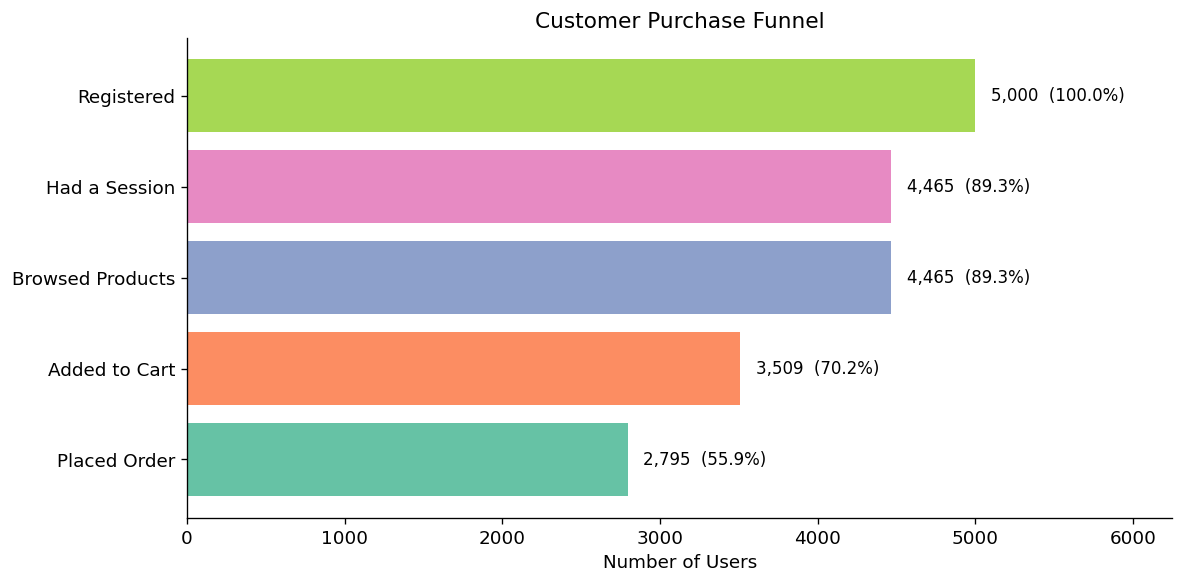

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(funnel['Stage'][::-1], funnel['Users'][::-1],
               color=[COLORS[i] for i in range(len(funnel))])

for bar, row in zip(bars, funnel[::-1].itertuples()):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{row.Users:,}  ({row._3}%)", va='center', fontsize=10)

ax.set_title('Customer Purchase Funnel', fontsize=13)
ax.set_xlabel('Number of Users')
ax.set_xlim(0, total_users * 1.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_purchase_funnel.png', bbox_inches='tight')
plt.show()

Order value by membership tier:


,count,mean,median,total
membership,,,,
free,1629,764.370,798.110,1245151.040
silver,771,738.910,731.030,569700.340
gold,4085,746.760,739.470,3050518.960
platinum,1515,749.040,736.950,1134800.090


TypeError: Axes.boxplot() got an unexpected keyword argument 'order'

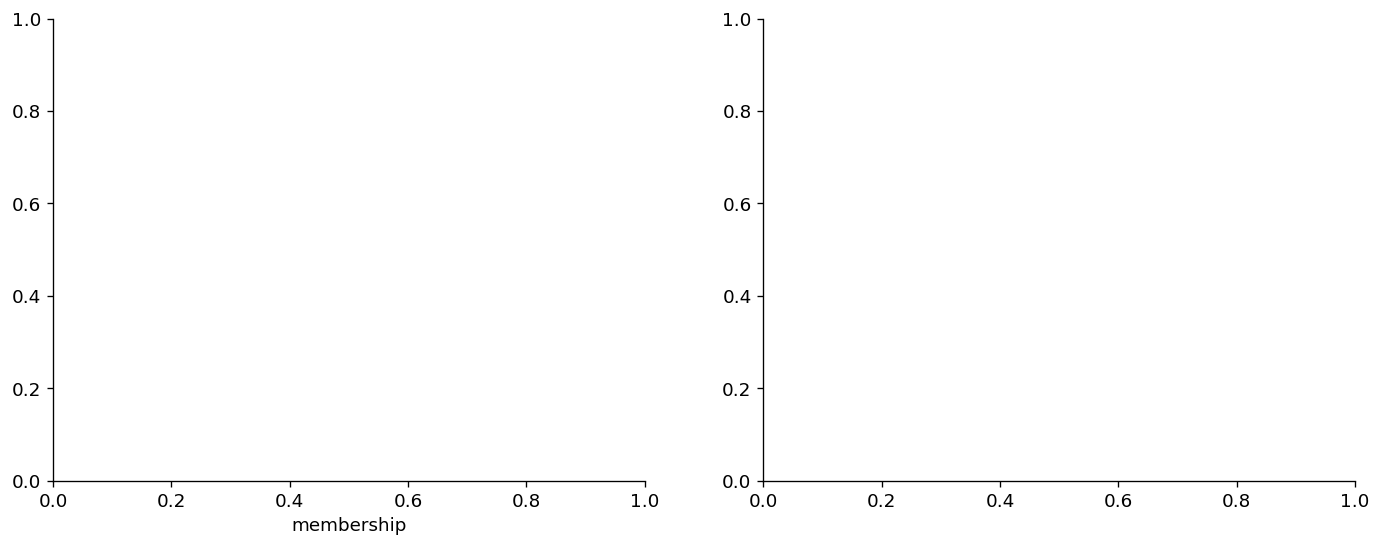

In [8]:
# Order value analysis by membership tier
merged = orders.merge(users[['user_id','membership','is_premium']], on='user_id', how='left')

tier_stats = merged.groupby('membership')['total_amount'].agg(
    count='count', mean='mean', median='median', total='sum'
).round(2)
tier_order = ['free','silver','gold','platinum']
tier_stats = tier_stats.reindex([t for t in tier_order if t in tier_stats.index])

print("Order value by membership tier:")
display(tier_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
merged.boxplot(column='total_amount', by='membership', ax=axes[0],
               order=[t for t in tier_order if t in merged['membership'].unique()])
axes[0].set_title('Order value by membership tier')
axes[0].set_xlabel('Membership')
plt.suptitle('')

tier_stats['total'].plot(kind='bar', ax=axes[1], edgecolor='white', color=COLORS)
axes[1].set_title('Total revenue by membership tier')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_revenue_by_tier.png', bbox_inches='tight')
plt.show()

## Step 4 — Product Performance Analysis

In [ ]:
# Top browsed products
top_browsed = (browse_events.groupby('product_id')
               .size().reset_index(name='browse_count')
               .merge(products[['product_id','product_name','category','price']], on='product_id')
               .sort_values('browse_count', ascending=False))

print("Top 10 most browsed products:")
display(top_browsed.head(10)[['product_name','category','price','browse_count']])

In [ ]:
# Top purchased products
top_sold = (order_items.groupby('product_id')
            .agg(orders_count=('order_id','nunique'),
                 units_sold=('quantity','sum'),
                 revenue=('unit_price', lambda x: (x * order_items.loc[x.index,'quantity']).sum()))
            .reset_index()
            .merge(products[['product_id','product_name','category','price']], on='product_id')
            .sort_values('revenue', ascending=False))

print("Top 10 products by revenue:")
display(top_sold.head(10)[['product_name','category','price','units_sold','revenue']])

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Browse count by category
cat_browse = (browse_events.merge(products[['product_id','category']], on='product_id')
              .groupby('category').size().sort_values(ascending=True))
cat_browse.plot(kind='barh', ax=axes[0], edgecolor='white', color=COLORS[0])
axes[0].set_title('Browse events by category')
axes[0].set_xlabel('Count')

# Revenue by category
cat_rev = top_sold.groupby('category')['revenue'].sum().sort_values(ascending=True)
cat_rev.plot(kind='barh', ax=axes[1], edgecolor='white', color=COLORS[1])
axes[1].set_title('Revenue by category')
axes[1].set_xlabel('USD')

# Price vs browse count scatter
merged_prod = top_browsed.merge(
    top_sold[['product_id','revenue']], on='product_id', how='left').fillna(0)
sc = axes[2].scatter(merged_prod['price'], merged_prod['browse_count'],
                     c=merged_prod['revenue'], cmap='viridis', alpha=0.6, s=40)
plt.colorbar(sc, ax=axes[2], label='Revenue ($)')
axes[2].set_title('Price vs Browse count
(color = revenue)')
axes[2].set_xlabel('Price ($)')
axes[2].set_ylabel('Browse count')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_product_analysis.png', bbox_inches='tight')
plt.show()

## Step 5 — RFM Analysis
**Recency · Frequency · Monetary** — the gold-standard framework for customer segmentation.
- **Recency**   — how recently did the user last order?
- **Frequency** — how many orders have they placed?
- **Monetary**  — how much have they spent in total?


In [ ]:
snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('user_id').agg(
    recency   = ('order_date',    lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id',      'count'),
    monetary  = ('total_amount',  'sum'),
).reset_index()

# Score each dimension 1–4 (4=best)
rfm['R_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def rfm_segment(row):
    if   row['RFM_score'] >= 10:                  return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3: return 'Loyal'
    elif row['R_score'] >= 3:                     return 'Recent Customers'
    elif row['F_score'] >= 3:                     return 'At Risk'
    elif row['RFM_score'] <= 5:                   return 'Lost'
    else:                                          return 'Potential'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

print("RFM Summary:")
print(rfm[['recency','frequency','monetary','RFM_score']].describe().round(1).to_string())

In [ ]:
seg_summary = rfm.groupby('segment').agg(
    count     = ('user_id',   'count'),
    avg_spend = ('monetary',  'mean'),
    avg_freq  = ('frequency', 'mean'),
    avg_rec   = ('recency',   'mean'),
).sort_values('avg_spend', ascending=False).round(1)

print("\nRFM Segment Summary:")
display(seg_summary)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Segment sizes
rfm['segment'].value_counts().plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Customer count per segment')
axes[0].tick_params(axis='x', rotation=20)

# Avg monetary per segment
seg_summary['avg_spend'].sort_values().plot(kind='barh', ax=axes[1], color=COLORS[1])
axes[1].set_title('Avg spend per segment ($)')
axes[1].set_xlabel('USD')

# RFM score distribution
rfm['RFM_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], edgecolor='white', color=COLORS[2])
axes[2].set_title('RFM score distribution')
axes[2].set_xlabel('Score (3=worst, 12=best)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_rfm_analysis.png', bbox_inches='tight')
plt.show()
print("Chart saved → 03_rfm_analysis.png")

## Step 6 — Correlation Analysis

In [ ]:
# Build a user-level feature matrix for correlation
user_features = (
    users[['user_id','age','membership_encoded','is_premium','account_age_days']]
    .merge(cart_signals[['user_id','total_events','total_cart_adds',
                          'unique_products_browsed','avg_time_per_event','cart_rate']],
           on='user_id', how='left')
    .merge(rfm[['user_id','recency','frequency','monetary','RFM_score']],
           on='user_id', how='left')
    .fillna(0)
)

# Drop ID column before correlation
corr_matrix = user_features.drop(columns=['user_id']).corr().round(3)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('User-level Feature Correlation Matrix', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Chart saved → 03_correlation_heatmap.png")

In [ ]:
# Top correlations with 'monetary' (our proxy for high-value customer)
if 'monetary' in corr_matrix.columns:
    top_corr = (corr_matrix['monetary']
                .drop('monetary')
                .abs()
                .sort_values(ascending=False)
                .head(8))
    print("Features most correlated with total spend (monetary):")
    print(top_corr.to_string())

## Step 7 — Key Insights Summary

In [ ]:
print("=" * 60)
print("  EDA KEY FINDINGS")
print("=" * 60)

# 1. Buyer rate
buyer_rate = len(orders['user_id'].unique()) / len(users) * 100
print(f"\n1. Buyer rate: {buyer_rate:.1f}% of users have ever purchased")

# 2. Bounce rate
if 'bounced' in sessions.columns:
    bounce = sessions['bounced'].mean() * 100
    print(f"2. Session bounce rate: {bounce:.1f}%")

# 3. Best membership tier
if 'membership' in merged.columns:
    best = merged.groupby('membership')['total_amount'].mean().idxmax()
    best_avg = merged.groupby('membership')['total_amount'].mean().max()
    print(f"3. Highest avg order value: {best} members (${best_avg:.2f})")

# 4. Top category
if 'category' in cat_rev.index.name or True:
    top_cat = cat_rev.idxmax()
    print(f"4. Top revenue category: {top_cat}")

# 5. Champions segment
champ = rfm[rfm['segment']=='Champions']
if len(champ):
    print(f"5. Champions: {len(champ)} users, avg spend ${champ['monetary'].mean():.2f}")

# 6. Cart rate
if 'cart_rate' in cart_signals.columns:
    avg_cart = cart_signals['cart_rate'].mean() * 100
    print(f"6. Average cart-add rate: {avg_cart:.1f}% of browse events")

# 7. Peak hour
if 'hour_of_day' in sessions.columns:
    peak_hour = sessions['hour_of_day'].value_counts().idxmax()
    print(f"7. Peak session hour: {peak_hour}:00")

print("\n" + "=" * 60)
print("  Proceed to Phase 4 — Feature Engineering")
print("=" * 60)

## ✅ Phase 3 Complete

### Charts saved to `reports/figures/`
| File | Content |
|---|---|
| `03_user_demographics.png` | Age, gender, device, membership distribution |
| `03_session_behavior.png` | Monthly trend, hourly pattern, engagement, bounce by source |
| `03_event_funnel.png` | Browse event type breakdown |
| `03_purchase_funnel.png` | Registration → session → browse → cart → order funnel |
| `03_revenue_by_tier.png` | Order value & revenue by membership tier |
| `03_product_analysis.png` | Category browse, revenue, price vs popularity |
| `03_rfm_analysis.png` | RFM customer segments |
| `03_correlation_heatmap.png` | Feature correlation matrix |

### ⏭️ Phase 4 — Feature Engineering
Open `04_feature_engineering.ipynb` — build the final feature matrix that feeds the ML model.
